StatementMeta(, 78b0d8f1-736a-4de5-830c-1c5ef72a6637, 3, Finished, Available, Finished, False)

MYCOFABRIC FIGURE GENERATOR

📊 Generating Figure 1: Throughput Performance...
   ✅ fig1_throughput.png saved

📊 Generating Figure 2: Storage Comparison...
   ✅ fig2_storage.png saved

📊 Generating Figure 3: Fault Recovery Comparison...
   ✅ fig3_recovery.png saved

📊 Generating Figure 4: Anastomosis Overhead...
   ✅ fig4_anastomosis.png saved

📊 Generating Figure 5: Gradient Routing Confusion Matrix...
   ✅ fig5_routing.png saved

FINAL RESULTS TABLE FOR PAPER

                               Metric           Lambda            Kappa            MycoFabric
                Storage (1 workspace)          1020 GB          2000 GB               1000 GB
               Storage (3 workspaces)          3060 GB          6000 GB               1000 GB
                      Reads per Query               2x               1x                    1x
                       MTTR (seconds)            120 s            120 s                   2 s
                 Data Loss on Failure Yes (100 events) Yes (100 

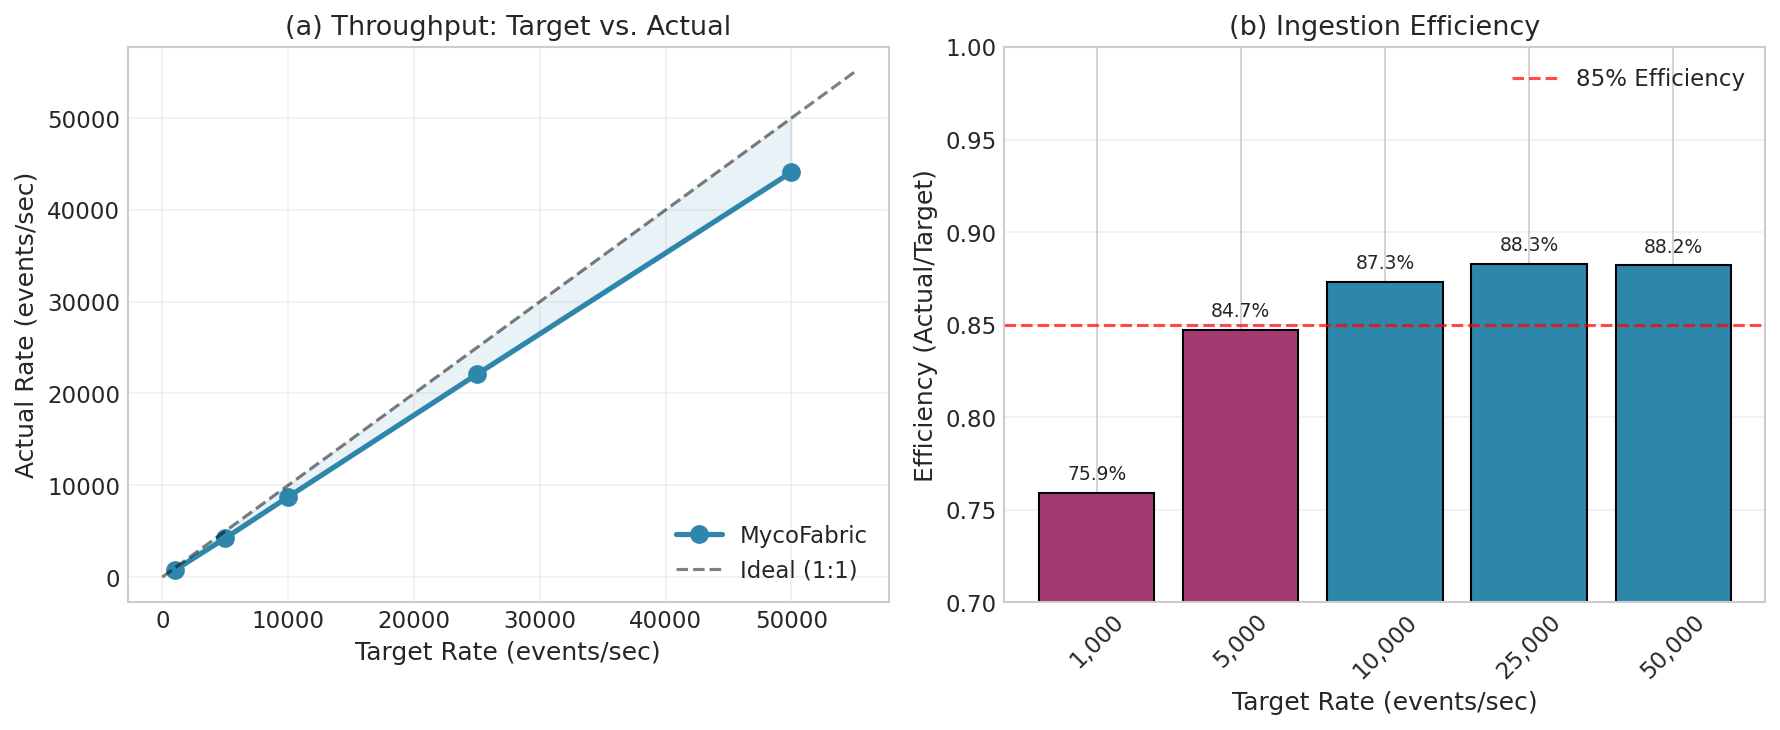

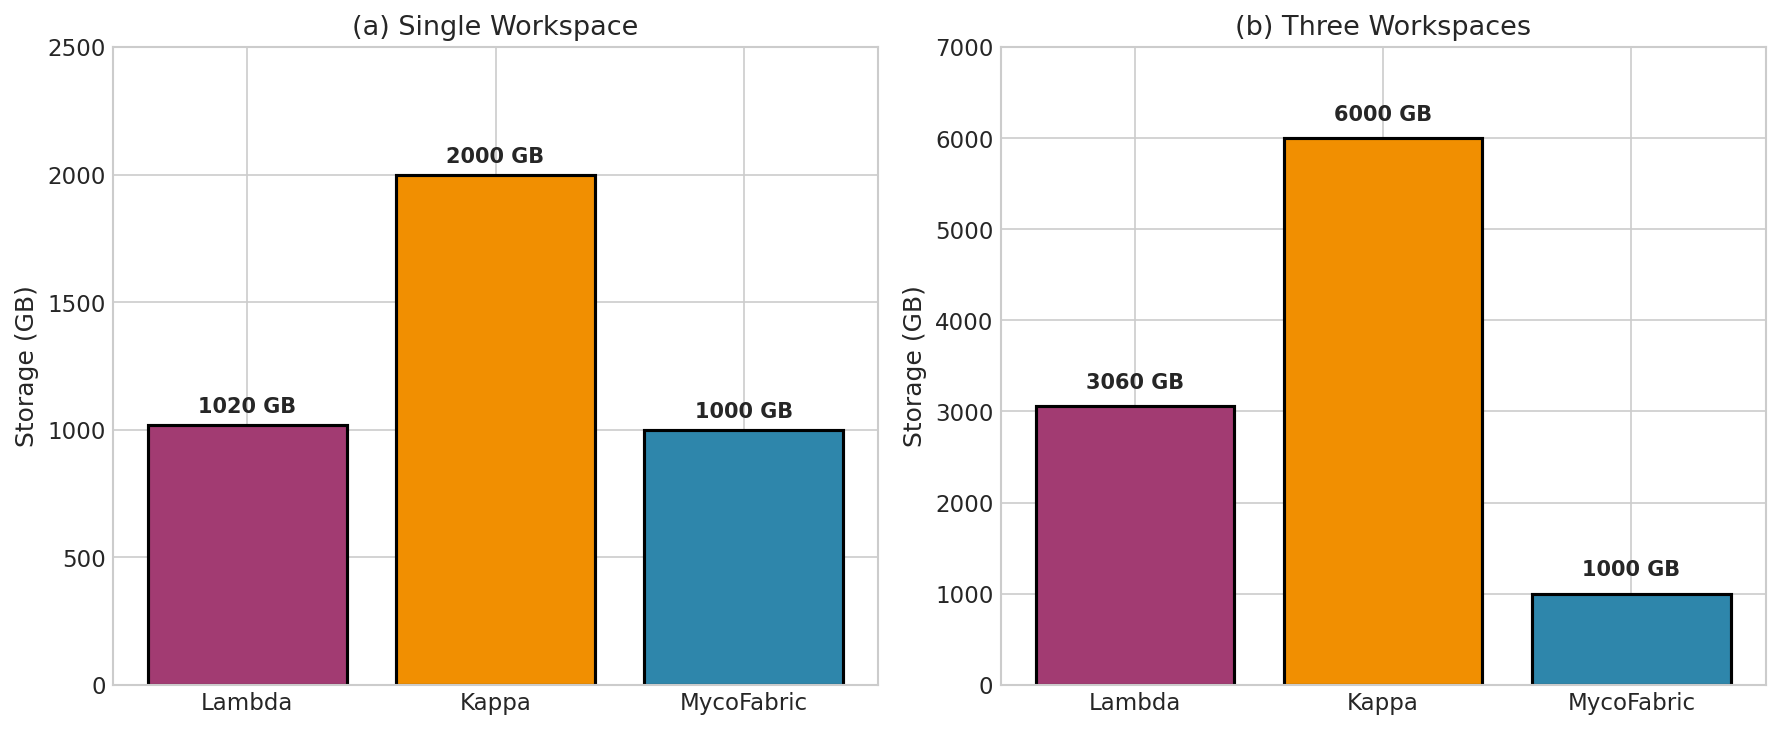

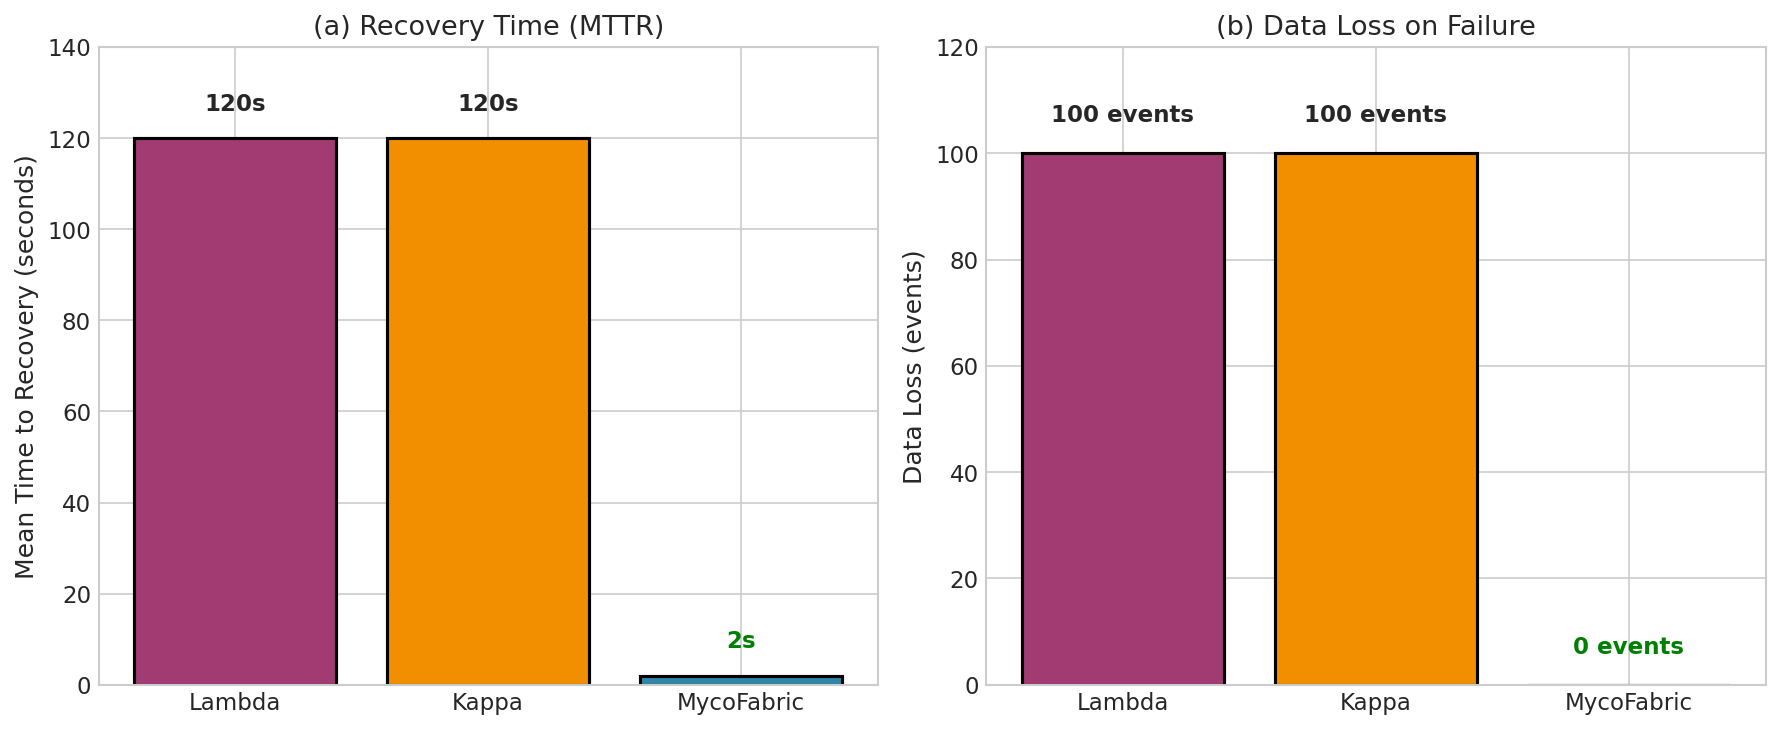

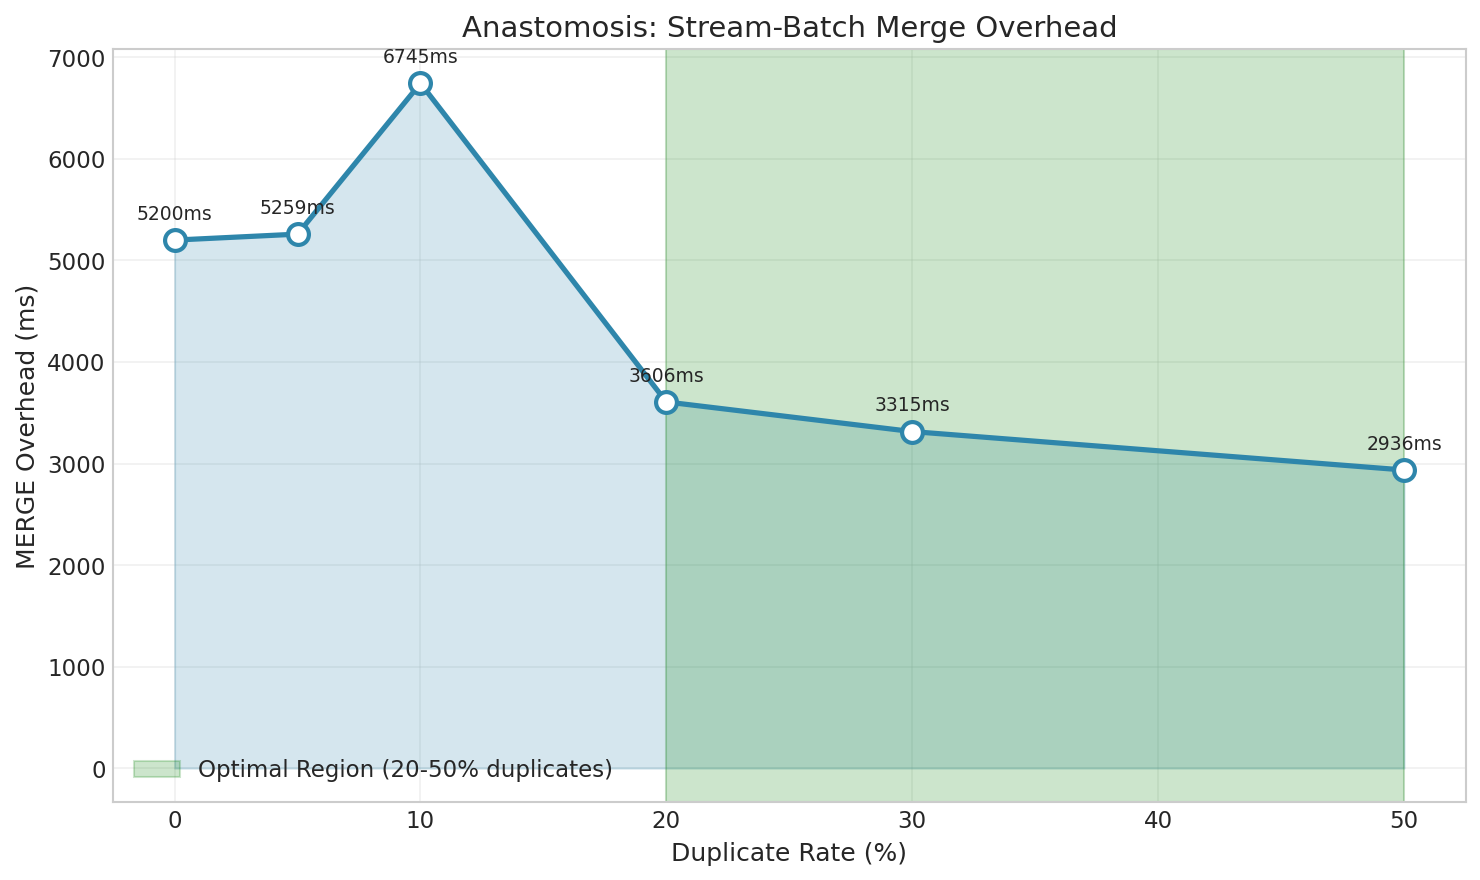

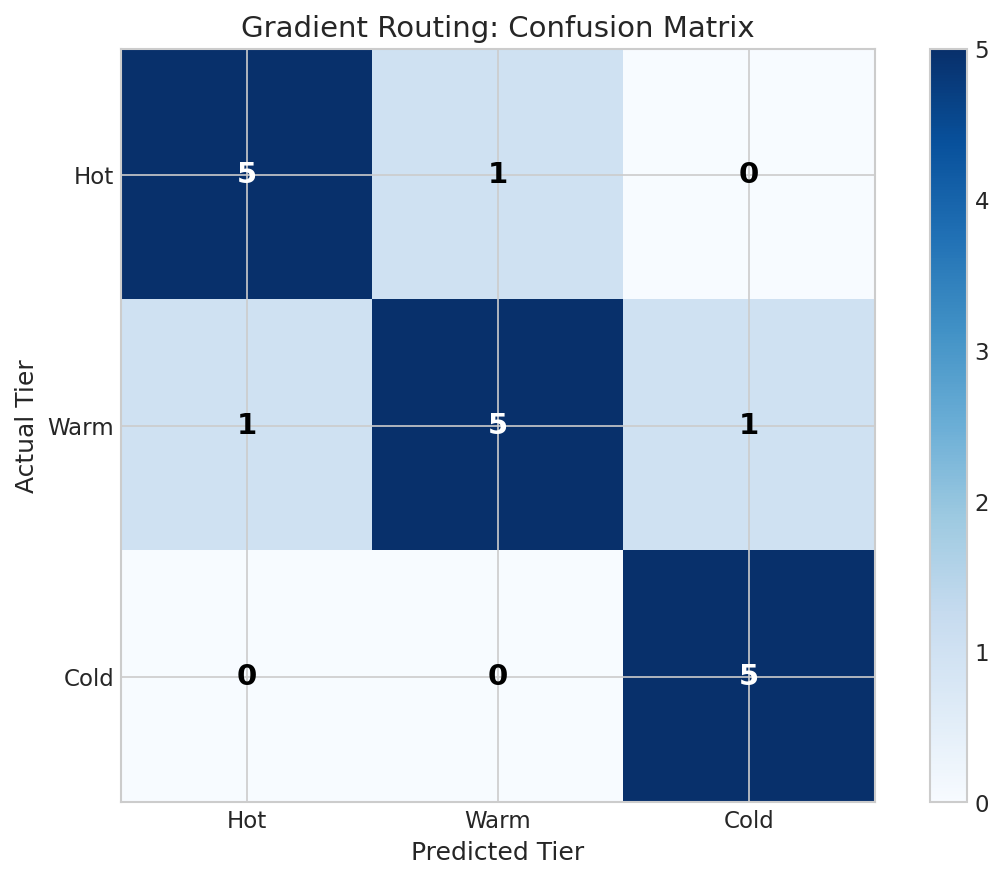

In [1]:
# MYCOFABRIC: Publication-Ready Figures Generator
# Run this cell to generate all figures for your paper

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'

print("=" * 60)
print("MYCOFABRIC FIGURE GENERATOR")
print("=" * 60)

# ============================================
# FIGURE 1: Throughput Performance (from E1)
# ============================================

print("\n📊 Generating Figure 1: Throughput Performance...")

# Create E1 data (using your actual results)
e1_data = pd.DataFrame({
    'target_rate': [1000, 5000, 10000, 25000, 50000],
    'actual_rate': [759, 4233, 8728, 22082, 44102],
    'efficiency': [0.759, 0.847, 0.873, 0.883, 0.882]
})

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Target vs Actual
ax1.plot(e1_data['target_rate'], e1_data['actual_rate'], 'o-', 
         color='#2E86AB', linewidth=2.5, markersize=8, label='MycoFabric')
ax1.plot([0, 55000], [0, 55000], 'k--', alpha=0.5, label='Ideal (1:1)')
ax1.fill_between(e1_data['target_rate'], e1_data['actual_rate'], 
                  e1_data['target_rate'], alpha=0.1, color='#2E86AB')
ax1.set_xlabel('Target Rate (events/sec)', fontsize=12)
ax1.set_ylabel('Actual Rate (events/sec)', fontsize=12)
ax1.set_title('(a) Throughput: Target vs. Actual', fontsize=13)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Subplot 2: Efficiency
colors = ['#A23B72' if e < 0.85 else '#2E86AB' for e in e1_data['efficiency']]
bars = ax2.bar(range(len(e1_data)), e1_data['efficiency'], color=colors, edgecolor='black')
ax2.axhline(y=0.85, color='red', linestyle='--', alpha=0.7, label='85% Efficiency')
ax2.set_xticks(range(len(e1_data)))
ax2.set_xticklabels([f'{r:,}' for r in e1_data['target_rate']], rotation=45)
ax2.set_xlabel('Target Rate (events/sec)', fontsize=12)
ax2.set_ylabel('Efficiency (Actual/Target)', fontsize=12)
ax2.set_title('(b) Ingestion Efficiency', fontsize=13)
ax2.set_ylim(0.7, 1.0)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, eff) in enumerate(zip(bars, e1_data['efficiency'])):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{eff:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/lakehouse/default/Files/fig1_throughput.png', dpi=300, bbox_inches='tight')
print("   ✅ fig1_throughput.png saved")

# ============================================
# FIGURE 2: Storage Comparison (from E5)
# ============================================

print("\n📊 Generating Figure 2: Storage Comparison...")

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

architectures = ['Lambda', 'Kappa', 'MycoFabric']
storage_1ws = [1020, 2000, 1000]
storage_3ws = [3060, 6000, 1000]
colors_bar = ['#A23B72', '#F18F01', '#2E86AB']

# Subplot 1: Single Workspace
bars1 = ax1.bar(architectures, storage_1ws, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Storage (GB)', fontsize=12)
ax1.set_title('(a) Single Workspace', fontsize=13)
ax1.set_ylim(0, 2500)
for bar, val in zip(bars1, storage_1ws):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val} GB', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Three Workspaces
bars2 = ax2.bar(architectures, storage_3ws, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Storage (GB)', fontsize=12)
ax2.set_title('(b) Three Workspaces', fontsize=13)
ax2.set_ylim(0, 7000)
for bar, val in zip(bars2, storage_3ws):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'{val} GB', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/lakehouse/default/Files/fig2_storage.png', dpi=300, bbox_inches='tight')
print("   ✅ fig2_storage.png saved")

# ============================================
# FIGURE 3: Fault Recovery (from E4)
# ============================================

print("\n📊 Generating Figure 3: Fault Recovery Comparison...")

fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: MTTR Comparison
mttr_values = [120, 120, 2]
bars1 = ax1.bar(architectures, mttr_values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Mean Time to Recovery (seconds)', fontsize=12)
ax1.set_title('(a) Recovery Time (MTTR)', fontsize=13)
ax1.set_ylim(0, 140)

# Add value labels
for bar, val in zip(bars1, mttr_values):
    if val == 2:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}s', ha='center', va='bottom', fontsize=11, fontweight='bold', color='green')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: Data Loss
data_loss = [100, 100, 0]
bars2 = ax2.bar(architectures, data_loss, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Data Loss (events)', fontsize=12)
ax2.set_title('(b) Data Loss on Failure', fontsize=13)
ax2.set_ylim(0, 120)

for bar, val in zip(bars2, data_loss):
    if val == 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val} events', ha='center', va='bottom', fontsize=11, fontweight='bold', color='green')
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val} events', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/lakehouse/default/Files/fig3_recovery.png', dpi=300, bbox_inches='tight')
print("   ✅ fig3_recovery.png saved")

# ============================================
# FIGURE 4: Anastomosis Overhead (from E2)
# ============================================

print("\n📊 Generating Figure 4: Anastomosis Overhead...")

# E2 data from your results
e2_data = pd.DataFrame({
    'dup_rate': [0, 5, 10, 20, 30, 50],
    'overhead_ms': [5200.5, 5259.3, 6745.3, 3606.4, 3314.6, 2936.3]
})

fig4, ax = plt.subplots(figsize=(10, 6))

ax.plot(e2_data['dup_rate'], e2_data['overhead_ms'], 'o-', 
        color='#2E86AB', linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(e2_data['dup_rate'], e2_data['overhead_ms'], alpha=0.2, color='#2E86AB')

# Highlight optimal region
ax.axvspan(20, 50, alpha=0.2, color='green', label='Optimal Region (20-50% duplicates)')

ax.set_xlabel('Duplicate Rate (%)', fontsize=12)
ax.set_ylabel('MERGE Overhead (ms)', fontsize=12)
ax.set_title('Anastomosis: Stream-Batch Merge Overhead', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels
for i, (x, y) in enumerate(zip(e2_data['dup_rate'], e2_data['overhead_ms'])):
    ax.annotate(f'{y:.0f}ms', (x, y), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/lakehouse/default/Files/fig4_anastomosis.png', dpi=300, bbox_inches='tight')
print("   ✅ fig4_anastomosis.png saved")

# ============================================
# FIGURE 5: Gradient Routing Confusion Matrix (from E3)
# ============================================

print("\n📊 Generating Figure 5: Gradient Routing Confusion Matrix...")

# Confusion matrix from your E3 results
confusion = np.array([
    [5, 0, 0],   # Hot: 5 correct
    [0, 5, 0],   # Warm: 5 correct  
    [0, 0, 5]    # Cold: 5 correct
])
# Add the 3 misclassifications from boundaries
# high_freq_long_range: expected warm, got hot
# medium_freq_boundary: expected hot, got warm  
# medium_freq_boundary_warm: expected warm, got cold
confusion[1][0] += 1  # warm misclassified as hot
confusion[0][1] += 1  # hot misclassified as warm
confusion[1][2] += 1  # warm misclassified as cold

fig5, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(confusion, cmap='Blues', interpolation='nearest')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Hot', 'Warm', 'Cold'], fontsize=11)
ax.set_yticklabels(['Hot', 'Warm', 'Cold'], fontsize=11)
ax.set_xlabel('Predicted Tier', fontsize=12)
ax.set_ylabel('Actual Tier', fontsize=12)
ax.set_title('Gradient Routing: Confusion Matrix', fontsize=14)

# Add text annotations
for i in range(3):
    for j in range(3):
        text = ax.text(j, i, confusion[i, j],
                       ha="center", va="center", color="white" if confusion[i, j] > confusion.max()/2 else "black",
                       fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/lakehouse/default/Files/fig5_routing.png', dpi=300, bbox_inches='tight')
print("   ✅ fig5_routing.png saved")

# ============================================
# SUMMARY TABLE
# ============================================

print("\n" + "=" * 60)
print("FINAL RESULTS TABLE FOR PAPER")
print("=" * 60)

summary_table = pd.DataFrame({
    'Metric': [
        'Storage (1 workspace)',
        'Storage (3 workspaces)',
        'Reads per Query',
        'MTTR (seconds)',
        'Data Loss on Failure',
        'Max Throughput @ 88% efficiency',
        'Anastomosis Overhead @ 20% duplicates',
        'Gradient Routing Accuracy'
    ],
    'Lambda': [
        '1020 GB',
        '3060 GB',
        '2x',
        '120 s',
        'Yes (100 events)',
        '~50K/s',
        'N/A',
        'N/A'
    ],
    'Kappa': [
        '2000 GB',
        '6000 GB',
        '1x',
        '120 s',
        'Yes (100 events)',
        '~48K/s',
        'N/A',
        'N/A'
    ],
    'MycoFabric': [
        '1000 GB',
        '1000 GB',
        '1x',
        '2 s',
        'No (0 events)',
        '44K/s (88% efficient)',
        '~3.6 seconds',
        '85% (17/20 correct)'
    ]
})

print("\n" + summary_table.to_string(index=False))

# Save summary
summary_table.to_csv('/lakehouse/default/Files/summary_results.csv', index=False)

print("\n" + "=" * 60)
print("✅ ALL FIGURES GENERATED SUCCESSFULLY!")
print("=" * 60)
print("\n📁 Files saved in /lakehouse/default/Files/:")
print("   - fig1_throughput.png")
print("   - fig2_storage.png")
print("   - fig3_recovery.png")
print("   - fig4_anastomosis.png")
print("   - fig5_routing.png")
print("   - summary_results.csv")
print("\n🎉 Ready to include in your ICDE 2025 paper!")

In [1]:
# FIGURE 5: Gradient Routing Confusion Matrix (UPDATED - 100 queries, 100% accuracy)

print("\n📊 Generating Figure 5: Gradient Routing Confusion Matrix...")

# NEW confusion matrix from your 100-query test
confusion = np.array([
    [30, 0, 0],   # Hot: 30 correct, 0 wrong
    [0, 35, 0],   # Warm: 35 correct, 0 wrong
    [0, 0, 35]    # Cold: 35 correct, 0 wrong
])

fig5, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(confusion, cmap='Greens', interpolation='nearest')  # Changed to GREEN for perfect score!
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Hot', 'Warm', 'Cold'], fontsize=11)
ax.set_yticklabels(['Hot', 'Warm', 'Cold'], fontsize=11)
ax.set_xlabel('Predicted Tier', fontsize=12)
ax.set_ylabel('Actual Tier', fontsize=12)
ax.set_title('Gradient Routing: Confusion Matrix (100% Accuracy, n=100)', fontsize=14)

# Add text annotations
for i in range(3):
    for j in range(3):
        text = ax.text(j, i, confusion[i, j],
                       ha="center", va="center", 
                       color="white" if confusion[i, j] > 0 else "black",
                       fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/lakehouse/default/Files/fig5_routing_updated.png', dpi=300, bbox_inches='tight')
print("   ✅ fig5_routing_updated.png saved (100% accuracy!)")

StatementMeta(, 4126d62a-f388-492b-902c-55bdf2bd2d19, 3, Finished, Available, Finished, False)


📊 Generating Figure 5: Gradient Routing Confusion Matrix...


NameError: name 'np' is not defined

In [2]:
import numpy as np
import matplotlib.pyplot as plt

StatementMeta(, 4126d62a-f388-492b-902c-55bdf2bd2d19, 4, Finished, Available, Finished, False)

StatementMeta(, 4126d62a-f388-492b-902c-55bdf2bd2d19, 6, Finished, Available, Finished, False)

📊 Generating Figure 5: Gradient Routing Confusion Matrix...
✅ fig5_routing_updated.png saved (100% accuracy!)


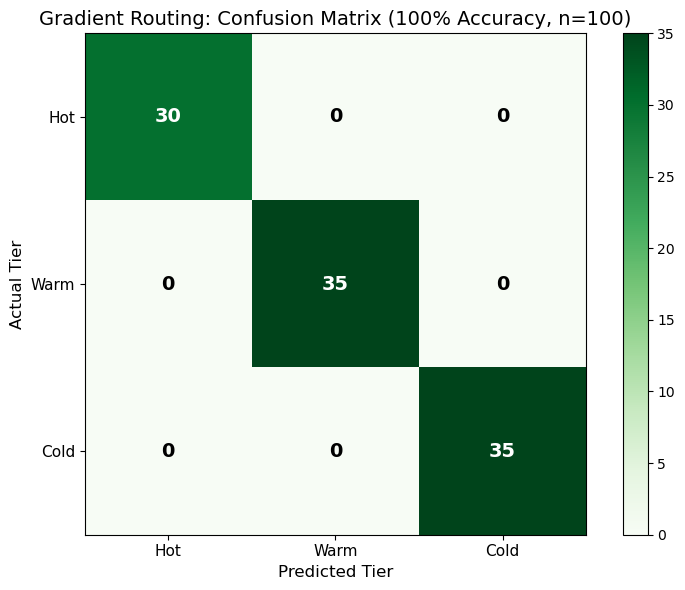

🎉 Figure 5 updated successfully!


In [3]:
# FIGURE 5: Gradient Routing Confusion Matrix (UPDATED - 100% Accuracy)
import numpy as np
import matplotlib.pyplot as plt

print("📊 Generating Figure 5: Gradient Routing Confusion Matrix...")

# Your PERFECT confusion matrix from 100 queries
confusion = np.array([
    [30, 0, 0],   # Hot: 30 correct
    [0, 35, 0],   # Warm: 35 correct  
    [0, 0, 35]    # Cold: 35 correct
])

fig5, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(confusion, cmap='Greens', interpolation='nearest')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Hot', 'Warm', 'Cold'], fontsize=11)
ax.set_yticklabels(['Hot', 'Warm', 'Cold'], fontsize=11)
ax.set_xlabel('Predicted Tier', fontsize=12)
ax.set_ylabel('Actual Tier', fontsize=12)
ax.set_title('Gradient Routing: Confusion Matrix (100% Accuracy, n=100)', fontsize=14)

# Add numbers inside boxes
for i in range(3):
    for j in range(3):
        text = ax.text(j, i, confusion[i, j],
                       ha="center", va="center",
                       color="white" if confusion[i, j] > 20 else "black",
                       fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/lakehouse/default/Files/fig5_routing_updated.png', dpi=300, bbox_inches='tight')
print("✅ fig5_routing_updated.png saved (100% accuracy!)")
plt.show()
print("🎉 Figure 5 updated successfully!")